In [45]:
import os
from os.path import exists as file_exists
import urllib
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
import osmnx as ox
import numpy as np
from shapely import wkt
import pyrosm
from fmm import Network, NetworkGraph, STMATCH, STMATCHConfig
from shapely.geometry import LineString
from zipfile import ZipFile
warnings.filterwarnings("ignore")


In [7]:
data = pd.read_parquet(
    ".." + os.sep + "data" + os.sep + "clean_data.parquet")


In [8]:
geo_data = gpd.GeoDataFrame(
    data,
    crs=4326,
    geometry=gpd.points_from_xy(data.longitude, data.latitude))


In [47]:
encoding = "utf-8"
filepath_nodes = "../data/nodes.shp"
filepath_edges = "../data/edges.shp"
url_download_trento_pbf = "https://osmit-estratti.wmcloud.org/dati/poly/comuni/pbf/022205_Trento_poly.osm.pbf"
pbf_filename = "trento_osm.pbf"
if (file_exists("trento_osm.pbf")): # == False):
    urllib.request.urlretrieve(
        url_download_trento_pbf, pbf_filename)
osm = pyrosm.OSM(pbf_filename)  # ,bounding_box=bounding_box)

In [69]:
# creation of the graph
nodes, edges = osm.get_network(network_type="driving", nodes=True)


In [70]:
G = osm.to_graph(nodes, edges, graph_type="networkx")


In [72]:
gdf_nodes, gdf_edges = ox.utils_graph.graph_to_gdfs(G)


In [73]:
# convert undirected graph to gdfs and stringify non-numeric columns
gdf_nodes = ox.io._stringify_nonnumeric_cols(gdf_nodes)
gdf_edges = ox.io._stringify_nonnumeric_cols(gdf_edges)
gdf_edges["fid"] = np.arange(0, gdf_edges.shape[0], dtype='int')
# save the nodes and edges as separate ESRI shapefiles
del gdf_nodes['osmid']
gdf_nodes.to_file(filepath_nodes, encoding=encoding)
gdf_edges.to_file(filepath_edges, encoding=encoding)
# scrivere procedura per creare zip file


In [162]:
network = Network("/home/napo/dev/escooter_trento/data/edges_32632.shp", "fid", "u", "v")
graph = NetworkGraph(network)



[2022-05-10 11:51:07.212] [info] [network.cpp:72] Read network from file /home/napo/dev/escooter_trento/data/edges_32632.shp
[2022-05-10 11:51:07.829] [info] [network.cpp:170] Number of edges 82502 nodes 43913
[2022-05-10 11:51:07.829] [info] [network.cpp:171] Field index: id 39 source 0 target 1
[2022-05-10 11:51:07.888] [info] [network.cpp:174] Read network done.
[2022-05-10 11:51:07.920] [info] [network_graph.cpp:17] Construct graph from network edges start
[2022-05-10 11:51:07.933] [info] [network_graph.cpp:30] Graph nodes 43913 edges 82502
[2022-05-10 11:51:07.934] [info] [network_graph.cpp:31] Construct graph from network edges end


In [126]:
id_trips = list(geo_data.trip_id.unique())

In [127]:
trip = geo_data[geo_data.trip_id == id_trips[1]]
trip.to_crs(epsg=32632, inplace=True)


In [128]:
trip.sort_values(by=["timestamp"], inplace=True)


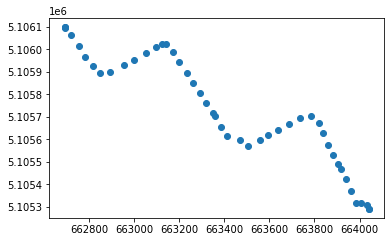

In [139]:
trip.plot()
plt.show()

In [130]:
points = []
strlinestring = "LINESTRING("
for idx,row in trip.iterrows():
    #points.append(wkt.loads(row.geometry.wkt))
    points.append(row.geometry)
    strlinestring = strlinestring + \
        str(row.geometry.x) + " " + str(row.geometry.y) +","
strlinestring = strlinestring.rstrip(",") + ")"

In [138]:
#LineString(points).wkt

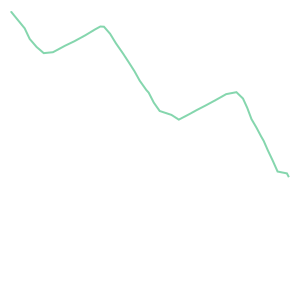

In [132]:
wkt.loads(LineString(points).wkt)


In [159]:
# istanzio le variabili per il map matching
model = STMATCH(network, graph)
k = 1  # number of candidates
gps_error = 1  # 0.003  # GPS error, unit is map_unit.
radius = 1  # 0.005  # search radius for candidates, unit is map_unit
vmax = 20  # maximum speed of the vehicle, unit is map_unit/second
stmatch_config = STMATCHConfig(k, radius, gps_error, vmax)


In [160]:
result = model.match_wkt(LineString(points).wkt, stmatch_config)
matched_path = list(result.cpath)
matched_edge_for_each_point = list(result.opath)
matched_edge_index = list(result.indices)
linestring_wkt = result.mgeom.export_wkt()
point_wkt = result.pgeom.export_wkt()

In [161]:
linestring_wkt


'LINESTRING()'

In [123]:
wkt.loads(linestring_wkt)


ParseException: Expected number but encountered ')'


WKTReadingError: Could not create geometry because of errors while reading input.

In [101]:
gpd.GeoDataFrame(
    {'id':[0],'geometry': [wkt.loads(linestring_wkt)]},
    crs='EPSG:4326',
    geometry='geometry').explore()



In [86]:
gpd.GeoDataFrame(
    {'id': [0], 'geometry': [wkt.loads(strlinestring)]},
    crs='EPSG:4326',
    geometry='geometry').explore()
